<a href="https://colab.research.google.com/github/kakopappa/Fine-tuning-LFM2.5-350M-on-Sharp-CV-P09FX-AC-Manual/blob/main/AC_Manual_Finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sharp CV-P09FX AC Manual Assistant

This notebook demonstrates fine-tuning the **LiquidAI/LFM2.5-350M** model using **Unsloth** and **QLoRA** to act as a specialized technical assistant for the Sharp CV-P09FX Portable Air Conditioner.

## 🚀 Project Overview
The goal is to transform a general-purpose lightweight language model into a domain-specific expert that provides accurate technical specifications (power requirements, fan modes, maintenance, etc.) based strictly on the product manual.

## 🛠️ Technical Configuration
To overcome the challenges of a small model (350M parameters) overriding its pre-trained knowledge, we utilized the following specialized settings:

*   **Framework**: [Unsloth](https://github.com/unslothai/unsloth) (2x faster fine-tuning).
*   **Quantization**: 4-bit QLoRA for efficient memory usage.
*   **LoRA Rank (r)**: 64 (Increased capacity for fact retention).
*   **LoRA Alpha**: 32.
*   **Epochs**: 30 (Extended training to ensure memorization of manual details).
*   **Learning Rate**: 2e-4.
*   **Prompt Format**: ChatML.

## 📂 Dataset Structure
The model is trained on a `.jsonl` file located at `./sample_data/ac_manual_chatml.jsonl`. Each entry follows the ChatML format:
```json
{
  "text": "<|im_start|>system\n...<|im_end|>\n<|im_start|>user\n...<|im_end|>\n<|im_start|>assistant\n...<|im_end|>"
}
```

## 📖 How to Use
1.  **Install Dependencies**: Run the first cell to install `unsloth`, `trl`, and `bitsandbytes`.
2.  **Fine-Tuning**: Run the training cell. It will load the base model, apply LoRA adapters, and save the result to `./lfm25_350m_ac_lora`.
3.  **Inference**: Run the inference cell to load the fine-tuned adapters. You can use the `ask()` function or the interactive loop to query the assistant.

## ⚠️ Important Note
If the model produces incorrect technical specs (e.g., wrong voltage), ensure the `SYSTEM_PROMPT` during inference matches the training prompt exactly: *\"Answer questions accurately based on the product manual.\"*

In [2]:
# Install necessary libraries
!pip install "unsloth[cu121-torch260]" trl datasets huggingface_hub hf_transfer bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.6/419.6 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225

In [10]:
# ============================================================
# Fine-tune LFM2.5-350M on Sharp CV-P09FX AC Manual Dataset
# Uses Unsloth + QLoRA + SFTTrainer
# ============================================================

import os
import torch
from datasets import load_dataset
from unsloth import FastLanguageModel, is_bfloat16_supported
from trl import SFTTrainer, SFTConfig

# ──────────────────────────────────────────────
# 1. CONFIG
# ──────────────────────────────────────────────
MODEL_NAME      = "LiquidAI/LFM2.5-350M"
DATASET_PATH    = "./sample_data/ac_manual_chatml.jsonl"
OUTPUT_DIR      = "./outputs"
LORA_SAVE_DIR   = "./lfm25_350m_ac_lora"

MAX_SEQ_LENGTH  = 512
LOAD_IN_4BIT    = True
LORA_RANK       = 64
LORA_ALPHA      = 32
LORA_DROPOUT    = 0.0
RANDOM_STATE    = 3407

# Training hyperparams
NUM_EPOCHS                  = 30    # Increased epochs further for better memorization
PER_DEVICE_TRAIN_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE               = 2e-4  # Increased slightly to help 'unlearn' base weights
WEIGHT_DECAY                = 0.01
WARMUP_STEPS                = 10
LR_SCHEDULER                = "cosine"
OPTIM                       = "adamw_8bit"
LOGGING_STEPS               = 1
SAVE_STEPS                  = 50
MAX_STEPS                   = -1

# 2. LOAD MODEL
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit = LOAD_IN_4BIT,
    trust_remote_code = True,
)

# 3. APPLY LoRA
model = FastLanguageModel.get_peft_model(
    model,
    r = LORA_RANK,
    target_modules = ["q_proj", "k_proj", "v_proj", "out_proj", "in_proj", "w1", "w2", "w3"],
    lora_alpha = LORA_ALPHA,
    lora_dropout = LORA_DROPOUT,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = RANDOM_STATE,
)

# 4. LOAD DATASET
dataset = load_dataset("json", data_files = DATASET_PATH, split = "train")

# 5. TRAINER
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = MAX_SEQ_LENGTH,
    args = SFTConfig(
        output_dir = OUTPUT_DIR,
        num_train_epochs = NUM_EPOCHS,
        per_device_train_batch_size = PER_DEVICE_TRAIN_BATCH_SIZE,
        gradient_accumulation_steps = GRADIENT_ACCUMULATION_STEPS,
        warmup_steps = WARMUP_STEPS,
        learning_rate = LEARNING_RATE,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = LOGGING_STEPS,
        optim = OPTIM,
        weight_decay = WEIGHT_DECAY,
        lr_scheduler_type = LR_SCHEDULER,
        seed = RANDOM_STATE,
        report_to = "none",
    ),
)

print("\nStarting training with 30 epochs...")
trainer.train()

model.save_pretrained(LORA_SAVE_DIR)
tokenizer.save_pretrained(LORA_SAVE_DIR)
print("Done training.")

Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.4.5: Fast Lfm2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Unsloth: Making `model.base_model.model.model` require gradients

Starting training with 30 epochs...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 45 | Num Epochs = 30 | Total steps = 180
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 23,986,176 of 378,470,144 (6.34% trained)


Step,Training Loss
1,5.425985
2,5.639862
3,5.228916
4,4.725238
5,4.427130
6,3.971867
7,3.717204
8,3.339155
9,3.196878
10,2.936101


Done training.


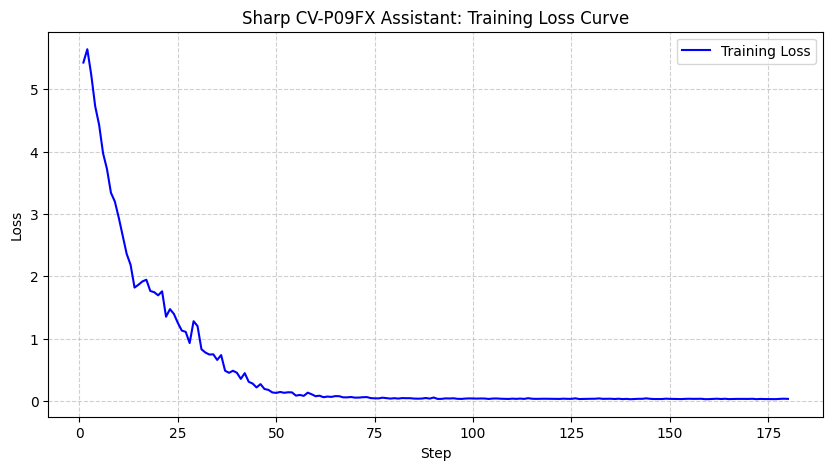

In [13]:
import matplotlib.pyplot as plt

# Extract logging history
history = trainer.state.log_history

# Filter for training loss entries
train_loss = [x['loss'] for x in history if 'loss' in x]
steps = [x['step'] for x in history if 'loss' in x]

# Plotting the training loss
plt.figure(figsize=(10, 5))
plt.plot(steps, train_loss, label='Training Loss', color='blue')
plt.title('Sharp CV-P09FX Assistant: Training Loss Curve')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
import json

def find_entry_with_question(filepath, question_keyword):
    with open(filepath, 'r') as f:
        for line in f:
            entry = json.loads(line)
            if question_keyword.lower() in entry['text'].lower():
                return entry
    return None

# Assuming DATASET_PATH is defined in a previous cell
question_to_check = "What power supply does the Sharp CV-P09FX require?"
found_entry = find_entry_with_question(DATASET_PATH, question_to_check)

if found_entry:
    print(f"Found entry in {DATASET_PATH} for '{question_to_check}':\n")
    print(found_entry['text'])
else:
    print(f"No entry found containing '{question_to_check}' in {DATASET_PATH}")

In [12]:
# ============================================================
# Inference — Test your fine-tuned LFM2.5-350M AC assistant
# Run AFTER train.py has completed
# ============================================================

import torch
from unsloth import FastLanguageModel

# ──────────────────────────────────────────────
# CONFIG — must match train.py settings
# ──────────────────────────────────────────────
LORA_SAVE_DIR  = "./lfm25_350m_ac_lora"
BASE_MODEL     = "LiquidAI/LFM2.5-350M"
MAX_SEQ_LENGTH = 512
LOAD_IN_4BIT   = True

SYSTEM_PROMPT = (
    "You are a helpful assistant for the Sharp CV-P09FX portable air conditioner. "
    "Answer questions accurately based on the product manual."
)

# Inference settings (recommended by Liquid AI)
GEN_CONFIG = dict(
    temperature      = 0.1,
    top_k            = 50,
    top_p            = 0.1,
    repetition_penalty = 1.05,
    max_new_tokens   = 256,
)

# ──────────────────────────────────────────────
# LOAD MODEL
# ──────────────────────────────────────────────
print(f"Loading base model + LoRA adapters from {LORA_SAVE_DIR}...")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = LORA_SAVE_DIR,   # Load LoRA adapter (contains base model ref)
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit   = LOAD_IN_4BIT,
)

FastLanguageModel.for_inference(model)  # Enable optimized inference mode

# Explicitly set pad_token_id for generation
if tokenizer.pad_token_id is None:
    if tokenizer.eos_token_id is not None:
        model.config.pad_token_id = tokenizer.eos_token_id
    else:
        # Fallback if neither pad_token_id nor eos_token_id is found
        model.config.pad_token_id = 0 # Or another appropriate default
else:
    model.config.pad_token_id = tokenizer.pad_token_id

print("Model ready.\n")


def ask(question: str) -> str:
    """Format a question in ChatML and run inference."""
    messages = [
        {"role": "system",    "content": SYSTEM_PROMPT},
        {"role": "user",      "content": question},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True,
        tokenize              = False,
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    print(tokenizer.decode(inputs["input_ids"][0]))
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            **GEN_CONFIG,
            pad_token_id = model.config.pad_token_id, # Use the explicitly set pad_token_id
        )

    # Decode only the newly generated tokens
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


# ──────────────────────────────────────────────
# TEST QUESTIONS
# ──────────────────────────────────────────────
test_questions = [
   #"What window widths are supported for installing the window panel?"
   # "How do I drain the water when the lamps are blinking?",
   # "What fan speeds are available in Cool mode?",
   # "How often should I clean the air filter?",
   # "Why do I need to wait 3 minutes before restarting the unit?",
    "What power supply does the Sharp CV-P09FX require?",
]

print("=" * 60)
print("  Fine-tuned LFM2.5-350M — AC Manual Assistant")
print("=" * 60)

for q in test_questions:
    print(f"\nQ: {q}")
    answer = ask(q)
    print(f"A: {answer}")
    print("-" * 60)

# ──────────────────────────────────────────────
# INTERACTIVE MODE
# ──────────────────────────────────────────────
print("\n\nEntering interactive mode. Type 'quit' to exit.\n")
while True:
    user_input = input("Your question: ").strip()
    if user_input.lower() in ("quit", "exit", "q"):
        print("Goodbye!")
        break
    if not user_input:
        continue
    print(f"\nAnswer: {ask(user_input)}\n")

Loading base model + LoRA adapters from ./lfm25_350m_ac_lora...
==((====))==  Unsloth 2026.4.5: Fast Lfm2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Model ready.

  Fine-tuned LFM2.5-350M — AC Manual Assistant

Q: What power supply does the Sharp CV-P09FX require?
<|startoftext|><|startoftext|><|im_start|>system
You are a helpful assistant for the Sharp CV-P09FX portable air conditioner. Answer questions accurately based on the product manual.<|im_end|>
<|im_start|>user
What power supply does the Sharp CV-P09FX require?<|im_end|>
<|im_start|>assistant

A: The unit requires a three-pin grounded electrical AC socket rated 125V, 60Hz, and 15 amps or more. Do not use extension cords. The power plug has a built-in fuse and must always be checked before use using the RESET and TEST buttons on the plug.
------------------------------------------------------------


Entering interactive mode. Type 'quit' to exit.

Your question: Can the unit freeze up and how do I prevent it?


Both `max_new_tokens` (=256) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|startoftext|><|startoftext|><|im_start|>system
You are a helpful assistant for the Sharp CV-P09FX portable air conditioner. Answer questions accurately based on the product manual.<|im_end|>
<|im_start|>user
Can the unit freeze up and how do I prevent it?<|im_end|>
<|im_start|>assistant


Answer: Yes, freezing can occur when the unit is set close to 64°F in low ambient temperature conditions, especially at night. To prevent freezing, set the unit to a higher temperature. If the cooling coil is already frozen, run the unit in Fan mode at HIGH speed until all ice has melted.



KeyboardInterrupt: Interrupted by user